## Stock Price Prediction

In [1]:
# import some inportant libaray

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader as data
import datetime as dt


#### Yahoo finance : to get stock data libary name : yfinance 

In [2]:
import yfinance as yf

stock="AAPL"  # Apple Inc. stock symbol

start=dt.datetime(2012,1,1)  # Start date for data retrieval
end=dt.datetime(2026,4,3)  # End date for data retrieval

df=yf.download(stock,start,end)  # Download stock data using yfinance

[*********************100%***********************]  1 of 1 completed


In [3]:
df  # Display the first few rows of the DataFrame

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2012-01-03,12.321690,12.359743,12.254873,12.266858,302220800
2012-01-04,12.387903,12.425058,12.263257,12.284831,260022000
2012-01-05,12.525436,12.541017,12.364834,12.433151,271269600
2012-01-06,12.656376,12.666863,12.561094,12.577573,318292800
2012-01-09,12.636298,12.816676,12.624912,12.749259,394024400
...,...,...,...,...,...
2026-03-27,248.800003,255.490005,248.070007,253.899994,47900000
2026-03-30,246.630005,250.869995,245.509995,250.070007,39446200


In [4]:
df.shape

(3583, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3583 entries, 2012-01-03 to 2026-04-02
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   3583 non-null   float64
 1   (High, AAPL)    3583 non-null   float64
 2   (Low, AAPL)     3583 non-null   float64
 3   (Open, AAPL)    3583 non-null   float64
 4   (Volume, AAPL)  3583 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 168.0 KB


In [6]:
df.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [7]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,3583.000000,3583.000000,3583.000000,3583.000000,3.583000e+03
mean,90.226654,91.126437,89.251993,90.158845,1.700180e+08
std,77.986561,78.755514,77.154957,77.922968,1.635411e+08
min,11.874171,12.149947,11.709070,11.796334,1.791060e+07
25%,24.504164,24.803163,24.221788,24.604669,7.087255e+07
50%,47.544540,47.922829,47.226206,47.510023,1.115048e+08
75%,154.482025,157.065070,152.066099,155.013179,2.016454e+08
max,285.922455,288.350192,283.035157,285.932471,1.506120e+09


In [8]:
df=df.reset_index()

In [9]:
df

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2012-01-03,12.321690,12.359743,12.254873,12.266858,302220800
1,2012-01-04,12.387903,12.425058,12.263257,12.284831,260022000
2,2012-01-05,12.525436,12.541017,12.364834,12.433151,271269600
3,2012-01-06,12.656376,12.666863,12.561094,12.577573,318292800
4,2012-01-09,12.636298,12.816676,12.624912,12.749259,394024400
...,...,...,...,...,...,...
3578,2026-03-27,248.800003,255.490005,248.070007,253.899994,47900000
3579,2026-03-30,246.630005,250.869995,245.509995,250.070007,39446200
3580,2026-03-31,253.789993,255.479996,247.100006,247.910004,49598100


In [10]:
# save the data to csv file
df.to_csv("AAPL.csv")


# now load the data from csv file
df=pd.read_csv("AAPL.csv")

#### Candlestick

In [11]:
import plotly.graph_objects as go


fig = go.Figure(data=[go.Candlestick(
    x=df['Date'],
    open=df['Open'],
    high=df['High'],
    low=df['Low'],
    close=df['Close']
)])

fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()
  

In [12]:
# drop the date column
df=df.drop("Date",axis=1)

In [13]:
df.head()  # Display the first few rows of the DataFrame

,Price,Close,High,Low,Open,Volume
0,Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
1,0,12.32168960571289,12.359743102469352,12.254872558812515,12.26685803812144,302220800
2,1,12.387903213500977,12.425058186866142,12.263257470992423,12.284830526396293,260022000
3,2,12.525436401367188,12.541016722439506,12.364834198922539,12.43315062241969,271269600
4,3,12.656375885009766,12.666862778834131,12.56109372953894,12.57757336271972,318292800


In [14]:
df=df.iloc[1:,:]  # Remove the first row of the DataFrame
df.head()  # Display the first few rows of the DataFrame

,Price,Close,High,Low,Open,Volume
1,0,12.32168960571289,12.359743102469352,12.254872558812515,12.26685803812144,302220800
2,1,12.387903213500977,12.425058186866142,12.263257470992423,12.284830526396293,260022000
3,2,12.525436401367188,12.541016722439506,12.364834198922539,12.43315062241969,271269600
4,3,12.656375885009766,12.666862778834131,12.56109372953894,12.57757336271972,318292800
5,4,12.636298179626465,12.816675599093925,12.62491197703761,12.749259294537902,394024400


In [15]:
df['High']=pd.to_numeric(df['High'], errors='coerce')  # Convert 'High' column to numeric, coercing errors to NaN
df['Low']=pd.to_numeric(df['Low'], errors='coerce')  # Convert
df['Open']=pd.to_numeric(df['Open'], errors='coerce')  # Convert 'Open' column to numeric, coercing errors to NaN
df['Close']=pd.to_numeric(df['Close'], errors='coerce')  # Convert 'Close' column to numeric, coercing errors to NaN
df['Volume']=pd.to_numeric(df['Volume'], errors='coerce')  # Convert 'Volume' column to numeric, coercing errors to NaN
df.info()  # Display information about the DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3583 entries, 1 to 3583
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   3583 non-null   object 
 1   Close   3583 non-null   float64
 2   High    3583 non-null   float64
 3   Low     3583 non-null   float64
 4   Open    3583 non-null   float64
 5   Volume  3583 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 168.1+ KB


In [16]:
df=df.reset_index(drop=True)  # Reset the index of the DataFrame, dropping the old index
df.head()  # Display the first few rows of the DataFrame

,Price,Close,High,Low,Open,Volume
0,0,12.321690,12.359743,12.254873,12.266858,302220800
1,1,12.387903,12.425058,12.263257,12.284831,260022000
2,2,12.525436,12.541017,12.364834,12.433151,271269600
3,3,12.656376,12.666863,12.561094,12.577573,318292800
4,4,12.636298,12.816676,12.624912,12.749259,394024400


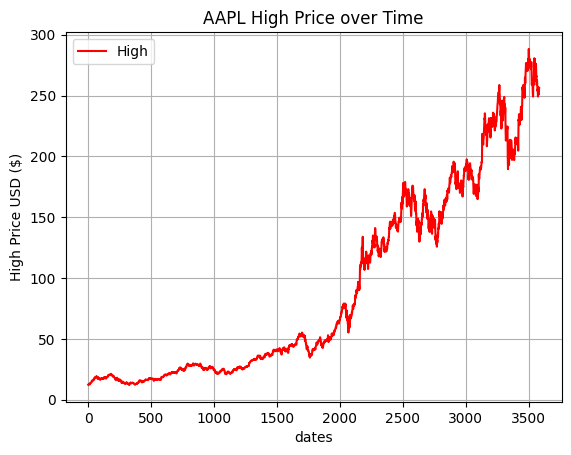

In [17]:
plt.Figure(figsize=(12,6))
plt.plot(df['High'],color='red', label="High")
plt.title(f"{stock} High Price over Time")
plt.xlabel("dates")
plt.ylabel("High Price USD ($)")
plt.legend()
plt.grid()
plt.show()

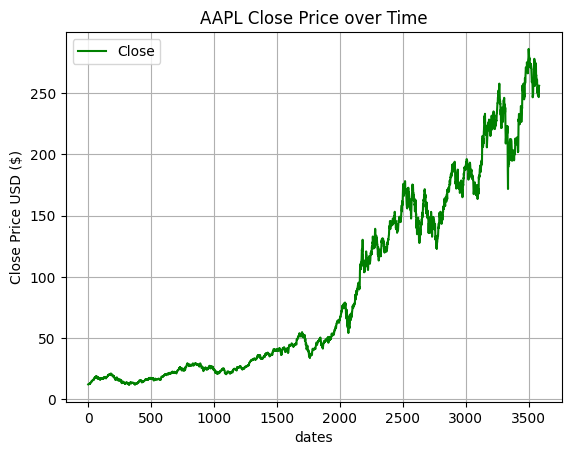

In [18]:
plt.Figure(figsize=(12,6))
plt.plot(df['Close'],color='green', label="Close")
plt.title(f"{stock} Close Price over Time")
plt.xlabel("dates")
plt.ylabel("Close Price USD ($)")
plt.legend()
plt.grid()
plt.show()

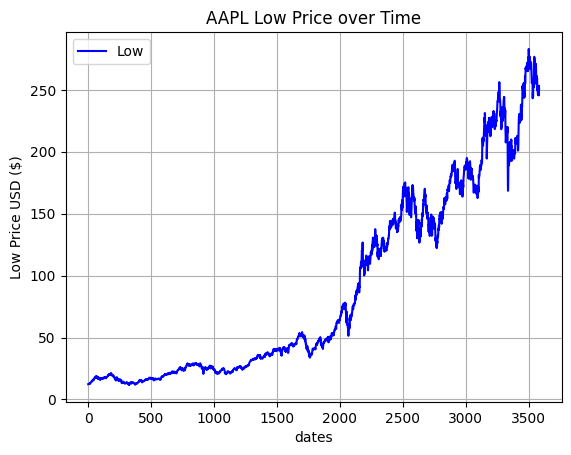

In [19]:
plt.Figure(figsize=(12,6))
plt.plot(df['Low'],color='blue', label="Low")
plt.title(f"{stock} Low Price over Time")
plt.xlabel("dates")
plt.ylabel("Low Price USD ($)")
plt.legend()
plt.grid()
plt.show()

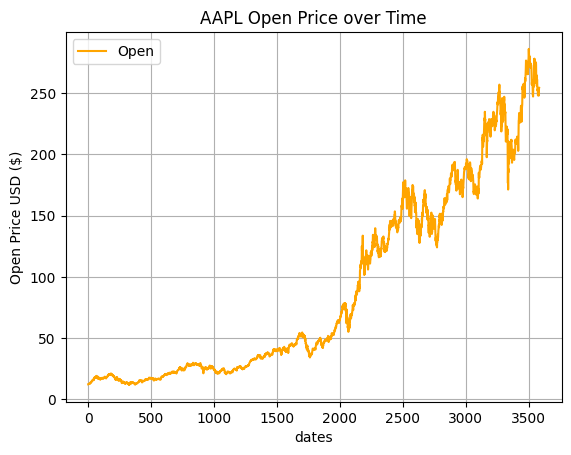

In [20]:
plt.Figure(figsize=(12,6))
plt.plot(df['Open'],color='orange', label="Open")
plt.title(f"{stock} Open Price over Time")
plt.xlabel("dates")
plt.ylabel("Open Price USD ($)")
plt.legend()
plt.grid()
plt.show()

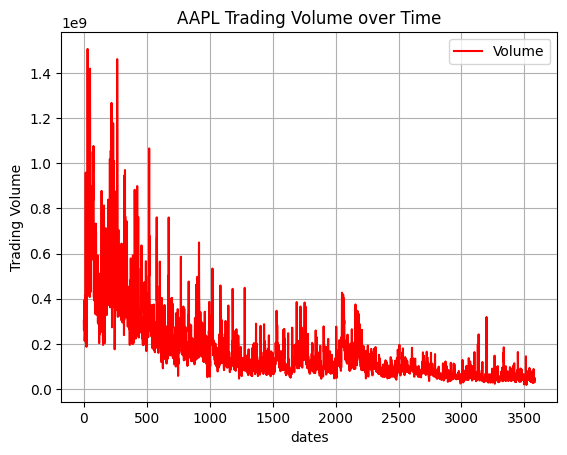

In [21]:
plt.Figure(figsize=(12,6))
plt.plot(df['Volume'],color='red', label="Volume")
plt.title(f"{stock} Trading Volume over Time")
plt.xlabel("dates")
plt.ylabel("Trading Volume")
plt.legend()
plt.grid()
plt.show()

### Moving average (MA)

##### MA : Moving Average is a commonly used technical indicator in stock price analysis that helps smooth out price data by creating a constantly updated average price. It is calculated by taking the average of a specific number of past closing prices. The moving average can be used to identify trends, support and resistance levels, and potential buy or sell signals in the stock market.

In [22]:
# Now calculate the moving average of the closing price with a window of 30 days
# ma30 stands for moving average with a window of 30 days 
df['MA30']=df['Close'].rolling(window=30).mean()  # Calculate
df['MA60']=df['Close'].rolling(window=60).mean()  # Calculate moving average with a window of 60 days

In [23]:
df

,Price,Close,High,Low,Open,Volume,MA30,MA60
0,0,12.321690,12.359743,12.254873,12.266858,302220800,NaN,NaN
1,1,12.387903,12.425058,12.263257,12.284831,260022000,NaN,NaN
2,2,12.525436,12.541017,12.364834,12.433151,271269600,NaN,NaN
3,3,12.656376,12.666863,12.561094,12.577573,318292800,NaN,NaN
4,4,12.636298,12.816676,12.624912,12.749259,394024400,NaN,NaN
...,...,...,...,...,...,...,...,...
3578,3578,248.800003,255.490005,248.070007,253.899994,47900000,258.879000,260.673463
3579,3579,246.630005,250.869995,245.509995,250.070007,39446200,258.574000,260.257200
3580,3580,253.789993,255.479996,247.100006,247.910004,49598100,258.237666,259.974422
3581,3581,255.630005,256.179993,253.330002,254.080002,40059400,257.947000,259.784753


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3583 entries, 0 to 3582
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   3583 non-null   object 
 1   Close   3583 non-null   float64
 2   High    3583 non-null   float64
 3   Low     3583 non-null   float64
 4   Open    3583 non-null   float64
 5   Volume  3583 non-null   int64  
 6   MA30    3554 non-null   float64
 7   MA60    3524 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 224.1+ KB


In [25]:

#df.dropna(inplace=True)  # Drop any rows with NaN values from the DataFrame

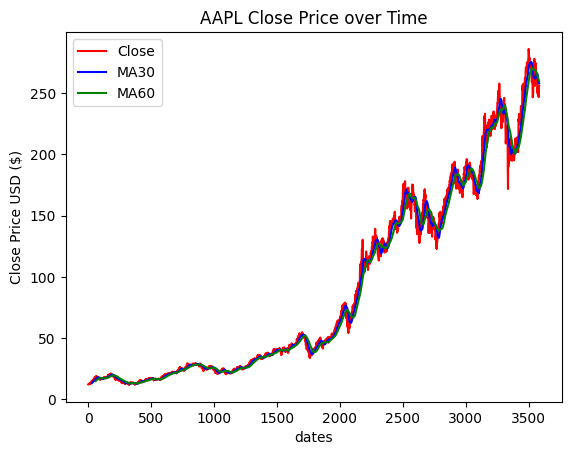

In [26]:
plt.Figure(figsize=(12,6))
plt.plot(df['Close'],color='red', label="Close")
plt.plot(df['MA30'],color='blue', label="MA30")
plt.plot(df['MA60'],color='green', label="MA60")
plt.title(f"{stock} Close Price over Time")
plt.xlabel("dates")
plt.ylabel("Close Price USD ($)")
plt.legend()
plt.show()

##### Prepare data for LSTM

In [27]:
# training and testing data split
train_size = int(len(df) * 0.8)  # Calculate the index for the training set (80% of the data)
test_size = len(df) - train_size  # Calculate the index for the testing set (20% of the data)

training_data = pd.DataFrame(df['Close'][:train_size])  # Create the training set
testing_data = pd.DataFrame(df['Close'][train_size:])  # Create the testing set

In [28]:
training_data.shape, testing_data.shape

((2866, 1), (717, 1))

In [29]:
training_data.head()

,Close
0,12.321690
1,12.387903
2,12.525436
3,12.656376
4,12.636298


In [30]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler(feature_range=(0,1))  # Create a MinMaxScaler object to scale the data to the range [0, 1]

In [31]:
data_training_array=scaler.fit_transform(training_data)  # Fit the scaler to the training data and transform it
data_training_array.shape

(2866, 1)

In [32]:
x_train=[]
y_train=[]

for i in range(60,data_training_array.shape[0]):
    x_train.append(data_training_array[i-60:i])  # Append the previous 60 data points to x_train
    y_train.append(data_training_array[i,0])  # Append the current data point (the target variable) to y_train


x_train=np.array(x_train)  # Convert x_train to a NumPy array
y_train=np.array(y_train)  # Convert y_train to a NumPy array

In [33]:
x_train

array([[[0.00269217],
        [0.0030905 ],
        [0.00391787],
        ...,
        [0.03797624],
        [0.03932817],
        [0.03989414]],

       [[0.0030905 ],
        [0.00391787],
        [0.00470557],
        ...,
        [0.03932817],
        [0.03989414],
        [0.03849541]],

       [[0.00391787],
        [0.00470557],
        [0.00458479],
        ...,
        [0.03989414],
        [0.03849541],
        [0.03663702]],

       ...,

       [[0.81449068],
        [0.79853935],
        [0.80571467],
        ...,
        [0.95033235],
        [0.95401401],
        [0.96802813]],

       [[0.79853935],
        [0.80571467],
        [0.80269025],
        ...,
        [0.95401401],
        [0.96802813],
        [0.96868115]],

       [[0.80571467],
        [0.80269025],
        [0.79023754],
        ...,
        [0.96802813],
        [0.96868115],
        [0.96298049]]], shape=(2806, 60, 1))

##### model building

In [34]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout


In [35]:
model=Sequential()  # Create a Sequential model


model.add(LSTM(units=50, activation='relu', return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])))  # Add an LSTM layer with 50 units and ReLU activation, returning sequences
model.add(Dropout(0.2))  # Add a Dropout layer with a dropout rate of 0.2 to prevent overfitting


model.add(LSTM(units=60, activation='relu', return_sequences=True))  # Add another LSTM layer with 60 units and ReLU activation, returning sequences
model.add(Dropout(0.3))  # Add another Dropout layer with a dropout rate of 0.3


model.add(LSTM(units=80, activation='relu'))  # Add a final LSTM layer with 80 units and ReLU activation, not returning sequences
model.add(Dropout(0.4))  # Add a Dropout layer with a dropout rate of 0.4


model.add(Dense(units=1))  # Add a Dense layer with 1 unit (the output layer)


c:\Users\91916\Desktop\HIMANSHU\MACHINE LEARNING\100DaysDL\Project\myenv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [36]:
model.summary()  # Print a summary of the model architecture

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 60)         │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 60)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 80)             │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            81 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,241 (321.25 KB)

 Trainable params: 82,241 (321.25 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.compile(optimizer='adam', loss='mean_squared_error')  # Compile the model with the Adam optimizer and mean squared error loss function    

model.fit(x_train, y_train, epochs=30)  # Train the model on the training data for 30 epochs

Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - loss: 0.0269
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0056
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0053
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0044
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0042
Epoch 6/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0042
Epoch 7/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - loss: 0.0040
Epoch 8/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0037
Epoch 9/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - loss: 0.0034
Epoch 10/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0031
Epoch 11/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0035
Epoch 12/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0031
Epoch 13/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - loss: 0.0030
Epoch 14/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0034
Epoch 15/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0032
Epo

In [38]:
past_60_days=training_data.tail(60)  # Get the last 60 days of the training data


In [39]:

final_df=pd.concat([past_60_days, testing_data], ignore_index=True)  # Append the testing data to the past 60 days of the training data, ignoring the index


In [40]:

final_df.head()  # Display the first few rows of the final DataFrame

,Close
0,145.304932
1,143.234924
2,143.826355
3,148.873260
4,151.633301


In [41]:
input_data=scaler.fit_transform(final_df)  # Fit the scaler to the final DataFrame and transform it

In [42]:
x_test=[]
y_test=[]

for i in range(60,input_data.shape[0]):
    x_test.append(input_data[i-60:i])  # Append the previous 60 data points to x_test
    y_test.append(input_data[i,0])  # Append the current data point (the target variable) to y_test


x_test=np.array(x_test)  # Convert x_test to a NumPy array
y_test=np.array(y_test)  # Convert y_test to a NumPy array

In [43]:
x_test.shape

(717, 60, 1)

In [44]:
y_predicted=model.predict(x_test)  # Use the trained model to make predictions on the test data

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step


In [45]:
y_predicted.shape

(717, 1)

In [46]:
# scale factor

scaler.scale_  # Get the scale factor used by the MinMaxScaler

array([0.00700832])

In [47]:
print(scaler.scale_[0])

0.007008320883910783


In [48]:
scale_factor=1/scaler.scale_[0]  # Calculate the scale factor for the target variable (the first feature)


y_predicted=y_predicted*scale_factor  # Scale the predicted values back to the original range
y_test=y_test*scale_factor  # Scale the actual values back to the original range

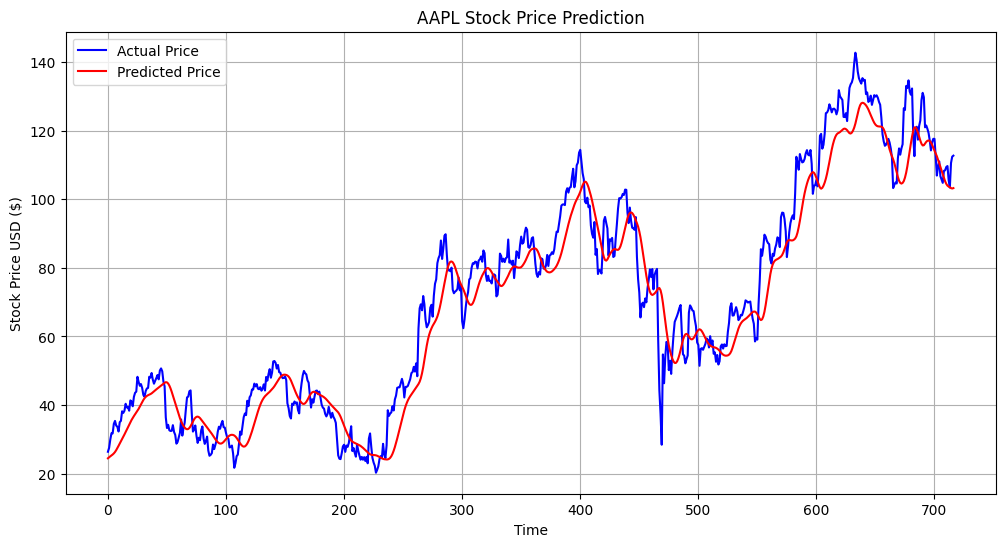

In [49]:
plt.figure(figsize=(12,6))
plt.plot(y_test, color='blue', label="Actual Price")  # Plot the actual prices in blue
plt.plot(y_predicted, color='red', label="Predicted Price")  # Plot the predicted prices in red 

plt.title(f"{stock} Stock Price Prediction")  # Set the title of the plot
plt.xlabel("Time")  # Set the x-axis label
plt.ylabel("Stock Price USD ($)")  # Set the y-axis label
plt.legend()  # Show the legend
plt.grid()  # Show the grid
plt.show()


In [50]:
model.save("Stock_model.h5")  # Save the trained model to a file named "keras_model.h5"